In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import ast

PATH_ACTIONS    = "../Data/Processed/actions_filtered.csv"
PATH_TEST       = "../Data/test_out.csv"
PATH_CLIPS      = "../Data/Videos/Clips/"

TEST_CLIP       = "1/11_Left.mp4"

In [4]:
df_actions = pd.read_csv(PATH_ACTIONS)
true_actions = df_actions[df_actions["file"] == TEST_CLIP]

print(true_actions)

            file fencer  action_id                 action  start_frame  \
2  1/11_Left.mp4   LEFT          2           ATTACK_LUNGE           60   
3  1/11_Left.mp4  RIGHT          3  DEFENSE_DISTANCE_PULL           22   
4  1/11_Left.mp4  RIGHT          4           ATTACK_BASIC           56   

   end_frame  
2         65  
3         40  
4         61  


In [5]:
df_test = pd.read_csv(PATH_TEST)

left_df = pd.DataFrame({
    "frame": df_test["frame_idx"],
    "fencer": "LEFT",
    "pred_label": df_test["left_label"],
    "keypoints": df_test["left_keypoints"],
})

right_df = pd.DataFrame({
    "frame": df_test["frame_idx"],
    "fencer": "RIGHT",
    "pred_label": df_test["right_label"],
    "keypoints": df_test["right_keypoints"],
})

df_test = pd.concat([left_df, right_df], ignore_index=True)
df_test.sort_values(["frame", "fencer"]).reset_index(drop=True)

print(df_test)

     frame fencer    pred_label  \
0        0   LEFT     NO_ACTION   
1        1   LEFT     NO_ACTION   
2        2   LEFT     NO_ACTION   
3        3   LEFT  ATTACK_BASIC   
4        4   LEFT  ATTACK_BASIC   
..     ...    ...           ...   
127     61  RIGHT  ATTACK_BASIC   
128     62  RIGHT  ATTACK_BASIC   
129     63  RIGHT  ATTACK_LUNGE   
130     64  RIGHT  ATTACK_LUNGE   
131     65  RIGHT  ATTACK_LUNGE   

                                             keypoints  
0    [[583.89013671875, 621.9039306640625], [586.03...  
1    [[590.4437255859375, 622.1222534179688], [592....  
2    [[598.7429809570312, 621.621337890625], [599.7...  
3    [[599.60009765625, 621.5570678710938], [600.58...  
4    [[605.3939819335938, 622.5609741210938], [606....  
..                                                 ...  
127  [[1553.217041015625, 603.349609375], [1556.284...  
128  [[1579.1478271484375, 597.2738647460938], [158...  
129  [[1585.3035888671875, 595.0828857421875], [158...  
130  [[15

In [6]:
merged = df_test.merge(
    true_actions[["fencer", "action", "start_frame", "end_frame"]],
    on="fencer",
    how="left"
)

valid = merged[
    (merged["frame"] >= merged["start_frame"]) &
    (merged["frame"] <= merged["end_frame"])
]

df_filtered = (
    valid[["fencer", "frame", "action", "pred_label", "keypoints"]]
    .drop_duplicates()
    .sort_values(["fencer", "frame"])
    .reset_index(drop=True)
)

df_filtered["keypoints"] = df_filtered["keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

print(df_filtered[["fencer", "frame", "action", "pred_label"]])

   fencer  frame                 action             pred_label
0    LEFT     60           ATTACK_LUNGE  DEFENSE_DISTANCE_PULL
1    LEFT     61           ATTACK_LUNGE  DEFENSE_DISTANCE_PULL
2    LEFT     62           ATTACK_LUNGE  DEFENSE_DISTANCE_PULL
3    LEFT     63           ATTACK_LUNGE           ATTACK_LUNGE
4    LEFT     64           ATTACK_LUNGE           ATTACK_LUNGE
5    LEFT     65           ATTACK_LUNGE           ATTACK_LUNGE
6   RIGHT     22  DEFENSE_DISTANCE_PULL           ATTACK_BASIC
7   RIGHT     23  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
8   RIGHT     24  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
9   RIGHT     25  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
10  RIGHT     26  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
11  RIGHT     27  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
12  RIGHT     28  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
13  RIGHT     29  DEFENSE_DISTANCE_PULL  DEFENSE_DISTANCE_PULL
14  RIGHT     30  DEFENSE_DISTANCE_PULL  DEFENSE_DISTAN

In [10]:
EDGES = [
    (0, 1), (1, 3),
    (3, 5), (1, 2),
    (0, 2), (2, 4),
    (4, 6),
    (5, 7), (7, 9),     # left arm
    (6, 8), (8, 10),    # right arm
    (5, 6),             # shoulders
    (11, 12),           # hips
    (5, 11), (6, 12),   # torso
    (11, 13), (13, 15), # left leg
    (12, 14), (14, 16)  # right leg
]

def plot_skeleton(frame, keypoints, color=(0,1,0), alpha=0.8):
    for (i,j) in EDGES:
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        plt.plot([x1, x2], [y1, y2], color=color, alpha=alpha, linewidth=2)
    keypoints = np.array(keypoints)
    plt.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)

def draw_random_frame(df):
    # Pick a random row from the dataframe
    row = df.sample(1).iloc[0]
    video_path = PATH_CLIPS + TEST_CLIP
    frame_idx = row["frame"]
    keypoints = row["keypoints"]

    # Open video
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        print(f"Failed to read frame {frame_idx}")
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,6))
    plt.imshow(frame_rgb)
    plt.axis("off")

    # Draw skeleton
    if keypoints and not (isinstance(keypoints, float) and np.isnan(keypoints)):
        plot_skeleton(frame_rgb, keypoints, color=(0,1,0))

    plt.title(f"Frame {frame_idx}, Fencer: {row['fencer']}, Action: {row['action']}, Prediction: {row['pred_label']}")
    plt.show()

    cap.release()

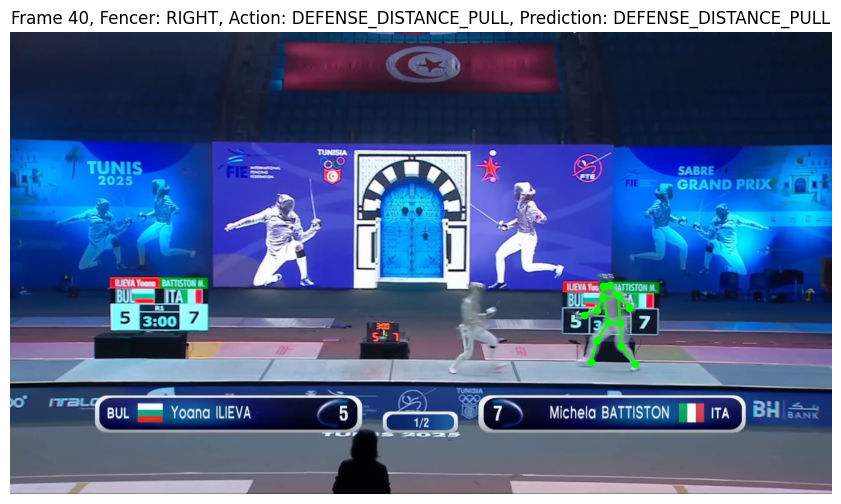

In [12]:
draw_random_frame(df_filtered)